In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import itertools as itt

from annotation_utils import load_marcotte_subtypes
from common import basedir, evaluations_dir
from sklearn.decomposition import PCA

model = "EGFR_MAPK__logobs"
data = "dream_cytof"

par_dev_df = pd.read_csv(evaluations_dir / model / data/ "param_devs_figure1a.csv", index_col=0)
# Subset to multimodal with best_RFE_10_permute
par_dev_df = par_dev_df[~((par_dev_df["context"] == "multimodal") &
                  (par_dev_df["features"] == "RFE_10_permute"))]
par_dev_df = par_dev_df[par_dev_df.samples.isin(["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"])]

not_param_cols = [
    "cell_line", "context", "model", "features", "samples", "dataset",
    "n_hidden", "depth", "l1reg_inflater_output", "inflater_output_reg_epoch", "l2reg_inflater_output",
    "recon_loss", "inflater_bound", "n_epoch", "job", ""
]
param_cols = [col for col in par_dev_df.columns if col not in not_param_cols]

median_par_dev_df = par_dev_df.groupby(["context", "features", "cell_line", "samples"])[param_cols].median().reset_index()


def pca_param_devs(par_dev_df):
    results_dfs = []
    for ctxt, split in itt.product(par_dev_df.context.unique(), par_dev_df.samples.unique()):
        sub_df = par_dev_df[(par_dev_df.context == ctxt) & (par_dev_df.samples == split)]
        # Compute median across job/multistart
        sub_df = sub_df.groupby(["context", "samples", "cell_line"])[param_cols].median().reset_index()
        sub_df.set_index("cell_line", inplace=True)
        pca = PCA(n_components=2)
        temp_res = pd.DataFrame(
            pca.fit_transform(sub_df[param_cols]),
            sub_df.index,
            columns=["PC1", "PC2"]
        ).assign(context=ctxt, samples=split)
        results_dfs.append(temp_res)
    return pd.concat(results_dfs)

pca_param_df = pca_param_devs(par_dev_df)

In [8]:
par_dev_df[(par_dev_df.context == "multimodal") & (par_dev_df.samples.isin(["MCF7", "HCC1500"])) & (par_dev_df.cell_line.isin(["cMCF7", "cHCC1500"]))]

,cell_line,ERBB2_dp_Y1248_kcat,EGFR_deg_kdeg,EGFR_dp_Y1173_kcat,EGFR_recycle_kcat,MEK_dp_S222_kcat,ERK_dp_Y204_kcat,RPS6KA1_dp_S380_kcat,ERBB2_p_Y1248_bact,ERBB2_p_Y1248_ERBB2_kw,...,job,n_hidden,depth,l1reg_inflater_output,l2reg_inflater_output,recon_loss,inflater_output_reg_epoch,n_epoch,inflater_bound,features
5384,cMCF7,-0.141950,0.0,-0.0,0.0,0.0,-0.0,0.0,0.000000,-1.140278,...,0,2,0,0.01,0,0.01,200,500,3,best_RFE_10_permute
5639,cMCF7,-0.112174,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.000000,-1.381518,...,1,2,0,0.01,0,0.01,200,500,3,best_RFE_10_permute
5894,cMCF7,-0.128250,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.000000,-1.105436,...,2,2,0,0.01,0,0.01,200,500,3,best_RFE_10_permute
6149,cMCF7,-0.145881,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.000000,-1.287337,...,3,2,0,0.01,0,0.01,200,500,3,best_RFE_10_permute
6404,cMCF7,-0.137717,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.000000,-1.055340,...,4,2,0,0.01,0,0.01,200,500,3,best_RFE_10_permute
6659,cMCF7,-0.104096,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.000000,-1.234475,...,5,2,0,0.01,0,0.01,200,500,3,best_RFE_10_permute
6914,cMCF7,-0.216995,-0.0,0.0,0.0,0.0,0.0,-0.0,0.000000,-1.218234,...,6,2,0,0.01,0,0.01,200,500,3,best_RFE_10_permute
7169,cMCF7,-0.222171,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.000000,-1.777752,...,7,2,0,0.01,0,0.01,200,500,3,best_RFE_10_permute
7424,cMCF7,-0.152107,0.0,0.0,-0.0,0.0,0.0,-0.0,-0.000000,-1.704060,...,8,2,0,0.01,0,0.01,200,500,3,best_RFE_10_permute
7679,cMCF7,-0.371765,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.000000,-1.216555,...,9,2,0,0.01,0,0.01,200,500,3,best_RFE_10_permute


In [23]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

def test_per_split(df: pd.DataFrame, param_cols: list[str], test_correction="fdr_bh", min_splits=3) -> pd.DataFrame:
    results = []

    # aggregate across jobs
    agg_df = (
        df.groupby(["context", "features", "samples", "cell_line"])[param_cols]
        .median()
        .reset_index()
    )

    # test within each CV split
    for (ctx, feat, split), group in agg_df.groupby(["context", "features", "samples"]):
        pvals, param_names = [], []
        for param in param_cols:
            values = group[param].dropna().values
            if len(values) < 5:
                continue
            try:
                _, p = wilcoxon(np.abs(values))
            except ValueError:
                p = 1.0
            pvals.append(p)
            param_names.append(param)

        if pvals:
            reject, pvals_corr, _, _ = multipletests(pvals, method=test_correction)
            for param, raw_p, corr_p, sig in zip(param_names, pvals, pvals_corr, reject):
                results.append({
                    "context": ctx,
                    "features": feat,
                    "split": split,
                    "parameter": param,
                    "pval_raw": raw_p,
                    "pval_corr": corr_p,
                    "significant": sig
                })

    per_split = pd.DataFrame(results)

    # aggregate across splits: keep only parameters significant in ≥ min_splits
    final = (
        per_split.groupby(["context", "features", "parameter"])["significant"]
        .sum()
        .reset_index(name="n_significant_splits")
    )
    final["robust"] = final["n_significant_splits"] >= min_splits

    return per_split, final

# Example usage:
param_cols = [
    c for c in par_dev_df.columns
    if c not in [
        "context", "features",
        "samples",
        "job",
        "cell_line",
        "dataset",
        "ref",
        "n_hidden",
        "depth",
        "l1reg_inflater_output",
        "l2reg_inflater_output",
        "inflater_bound",
        "inflater_output_reg_epoch",
        "recon_loss",
        "n_epoch"
    ]
]
# print(param_cols)
_, results_df = test_per_split(par_dev_df, param_cols, "bonferroni", 4)

# Results: per (context, features, parameter) with corrected significance
results_df

,context,features,parameter,n_significant_splits,robust
0,cytof_init,RFE_10_permute,EGFR_deg_bact,0,False
1,cytof_init,RFE_10_permute,EGFR_deg_kdeg,0,False
2,cytof_init,RFE_10_permute,EGFR_dp_Y1173_kcat,0,False
3,cytof_init,RFE_10_permute,EGFR_endo_EGFR__Y1173_p_kw,0,False
4,cytof_init,RFE_10_permute,EGFR_endo_EGFR_kw,1,False
...,...,...,...,...,...
131,transcriptomics,HVGRFE_10_permute,RPS6KA1_dp_S380_kcat,0,False
132,transcriptomics,HVGRFE_10_permute,RPS6KA1_p_S380_EGFR__Y1173_p_kw,5,True
133,transcriptomics,HVGRFE_10_permute,RPS6KA1_p_S380_ERBB2__Y1248_p_kw,3,False
134,transcriptomics,HVGRFE_10_permute,RPS6KA1_p_S380_ERK__Y204_p_kw,5,True


In [24]:
results_df.groupby(["context", "features"]).robust.sum()

context          features           
cytof_init       RFE_10_permute         16
multimodal       best_RFE_10_permute    15
proteomics       HVGRFE_10_permute      16
transcriptomics  HVGRFE_10_permute      15
Name: robust, dtype: int64

In [25]:
robust_params_multimodal = results_df[(results_df.context == "multimodal") & (results_df.robust)].parameter.unique().tolist()

In [26]:
robust_params_multimodal

['EGFR_p_Y1173_EGF_0_kw',
 'EGFR_p_Y1173_iEGFR_0_kw',
 'ERBB2_dp_Y1248_kcat',
 'ERBB2_p_Y1248_EGFR__Y1173_p_kw',
 'ERBB2_p_Y1248_ERBB2_kw',
 'ERBB2_p_Y1248_iEGFR_0_kw',
 'ERK_p_Y204_EGFR__Y1173_p_kw',
 'ERK_p_Y204_ERBB2__Y1248_p_kw',
 'ERK_p_Y204_iMEK_0_kw',
 'MEK_p_S222_EGFR__Y1173_p_kw',
 'MEK_p_S222_ERBB2__Y1248_p_kw',
 'MEK_p_S222_ERK__Y204_p_kw',
 'MEK_p_S222_bact',
 'RPS6KA1_p_S380_EGFR__Y1173_p_kw',
 'RPS6KA1_p_S380_ERK__Y204_p_kw']

In [27]:
median_jobs_pars = par_dev_df[(par_dev_df.context == "multimodal")][["cell_line", "samples"] + robust_params_multimodal].groupby(["cell_line", "samples"]).median().reset_index()

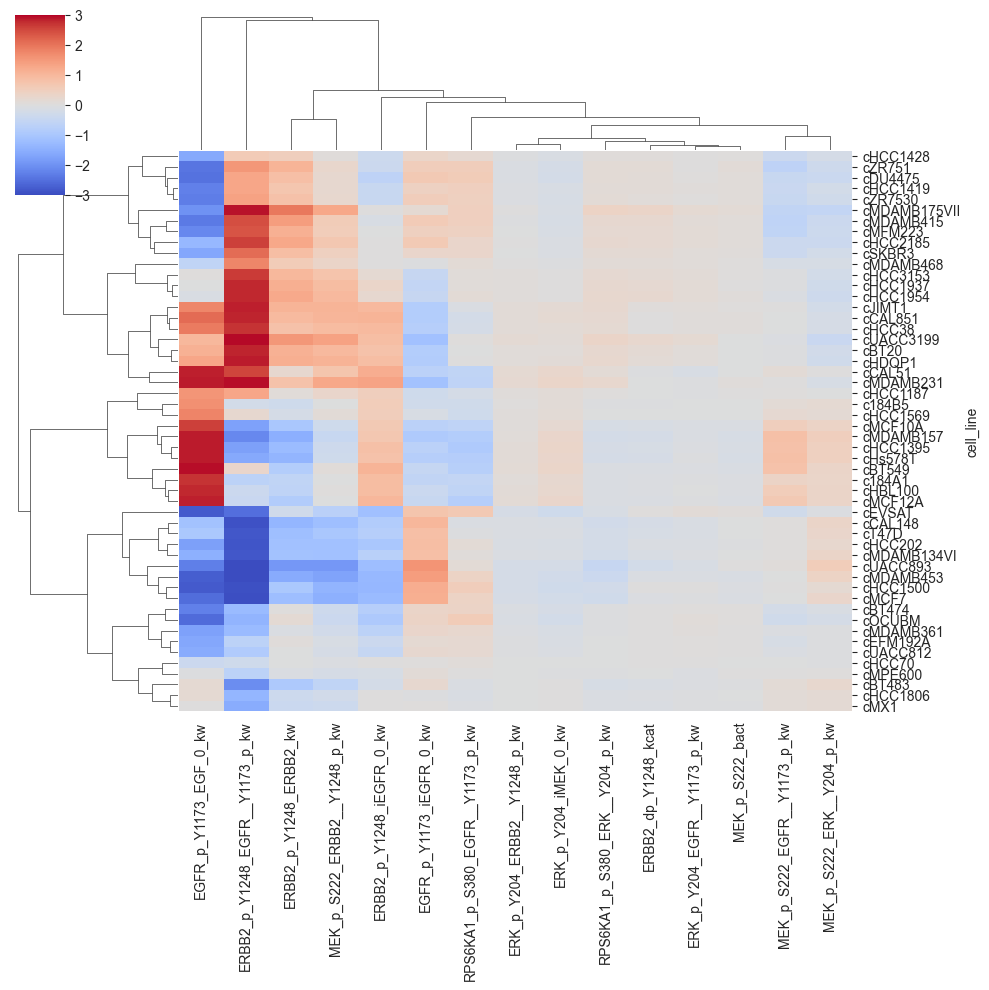

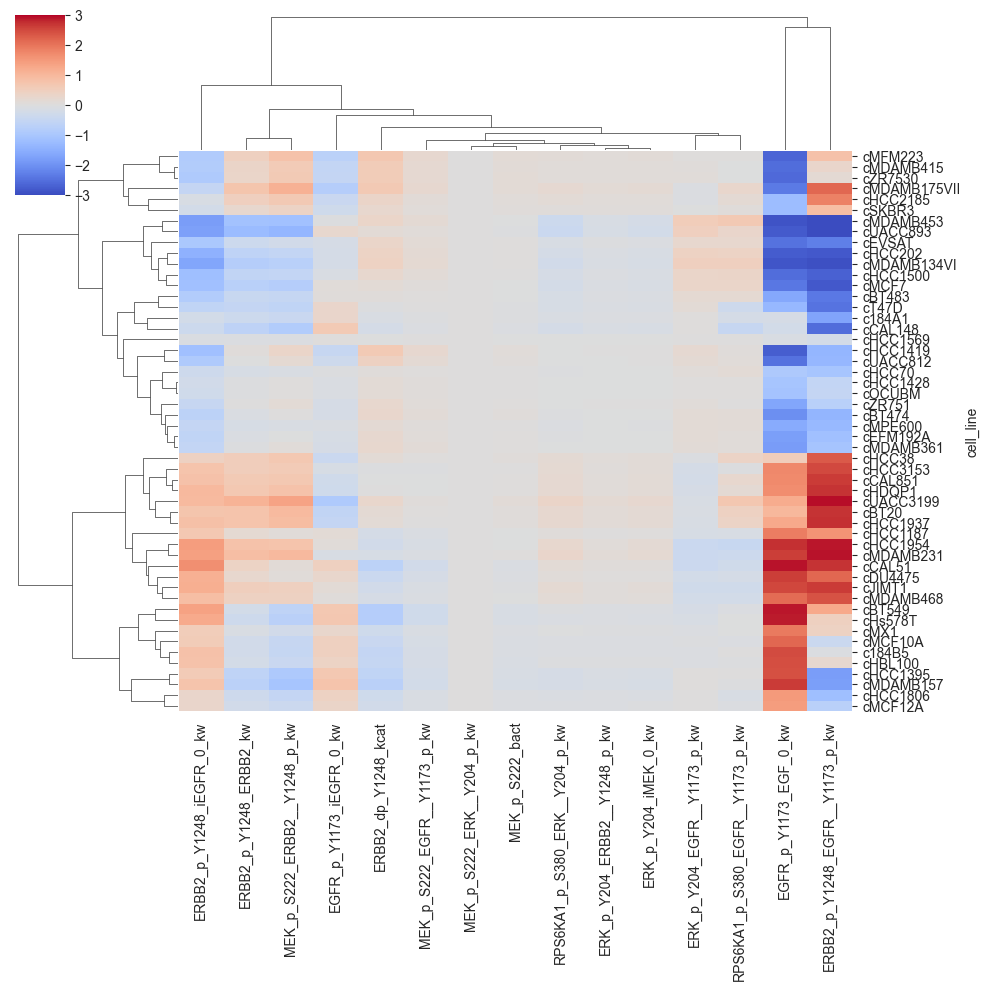

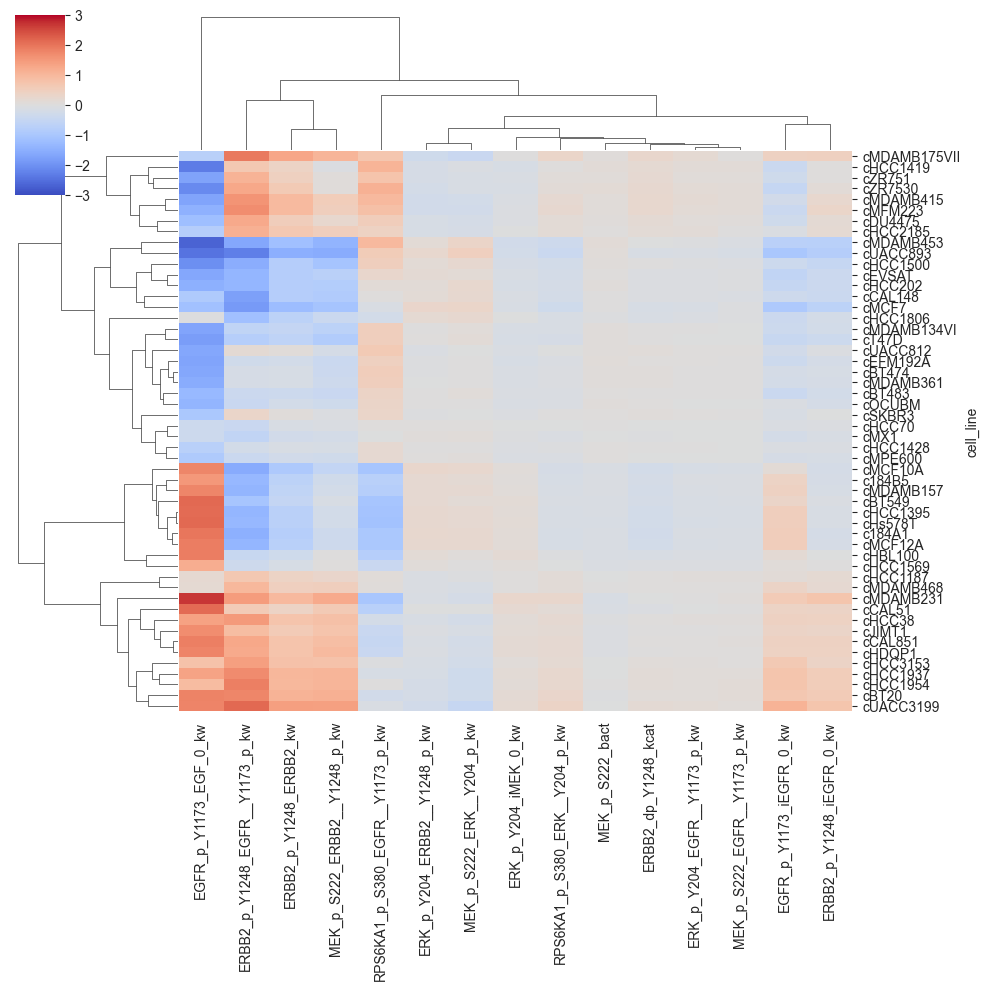

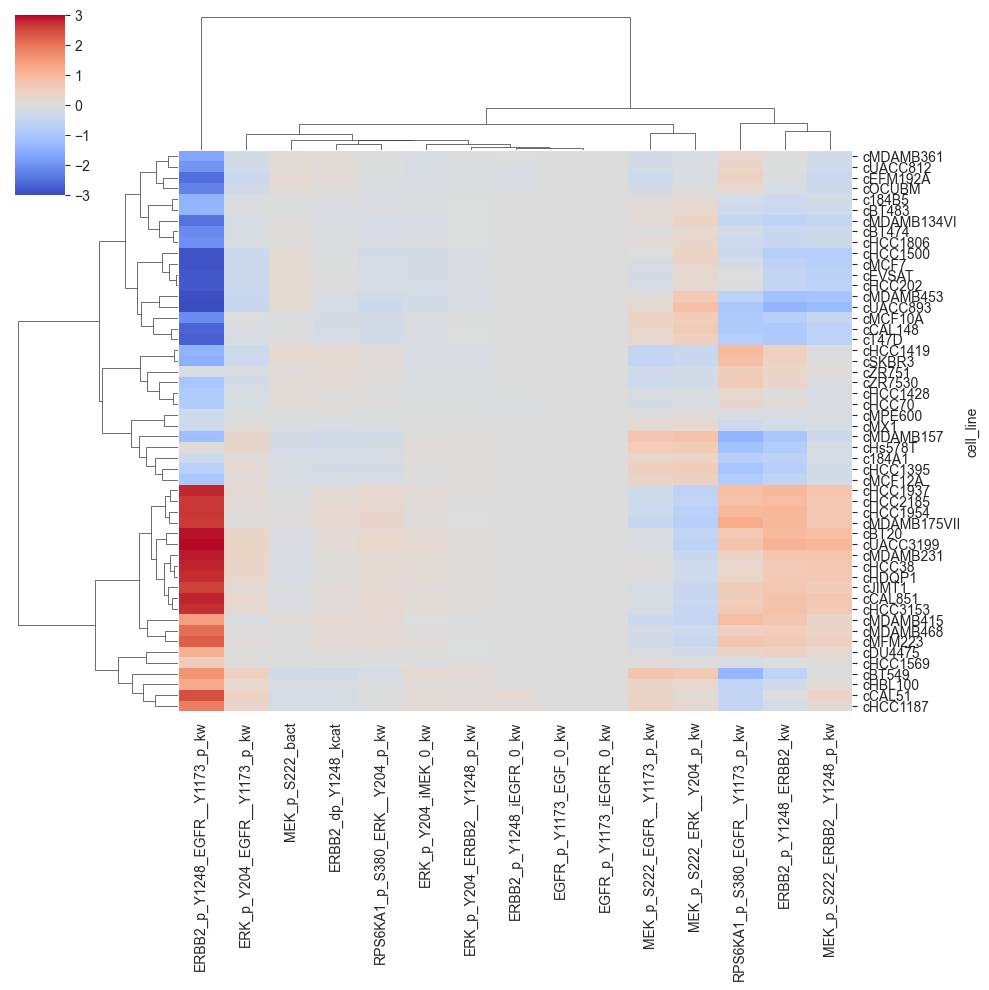

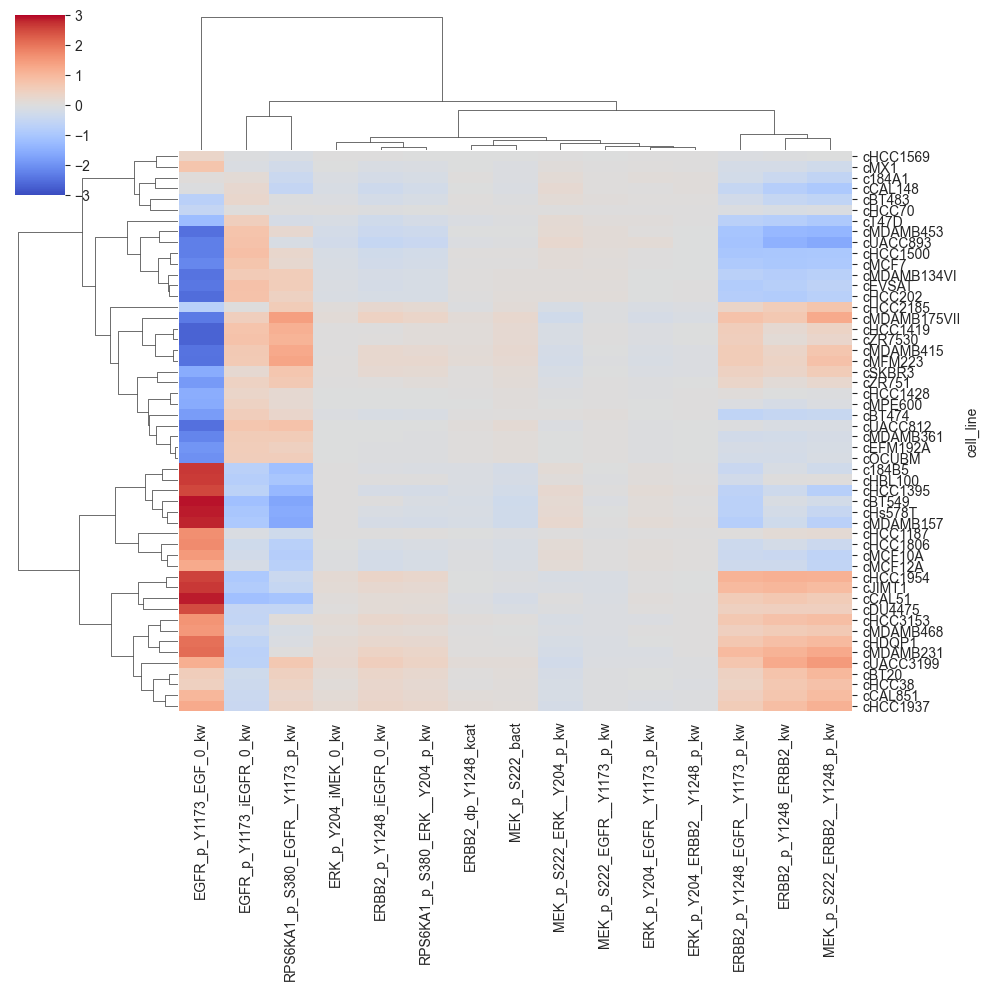

In [28]:
for samples in median_jobs_pars.samples.unique():
    sub_df = median_jobs_pars[median_jobs_pars.samples == samples]
    sub_df.set_index("cell_line", inplace=True)
    sns.clustermap(
        sub_df[robust_params_multimodal],
        cmap="coolwarm",
        vmin=-3,
        vmax=3,
        yticklabels=True,
        xticklabels=True,
    )
    plt.show()

In [29]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.stats import ranksums

def cluster_drivers(df: pd.DataFrame, param_cols: list[str], method="ward") -> pd.DataFrame:
    """
    Identify parameters that drive the biggest split in a clustermap-like clustering.
    """
    # 1. Matrix: rows = cell-lines (aggregated across jobs & splits), cols = params
    X = df.groupby(["context", "features", "cell_line"])[param_cols].median().reset_index()

    results = []
    for (ctx, feat), g in X.groupby(["context", "features"]):
        mat = g[param_cols].fillna(0).values

        # 2. Hierarchical clustering
        Z = linkage(mat, method=method)
        labels = fcluster(Z, t=2, criterion="maxclust")  # 2 clusters from biggest split

        # 3. Compare clusters per parameter
        for p in param_cols:
            vals = g[p].values
            cl1 = vals[labels == 1]
            cl2 = vals[labels == 2]
            if len(cl1) < 3 or len(cl2) < 3:
                continue
            stat, pval = ranksums(cl1, cl2)  # Wilcoxon rank-sum between clusters
            results.append({
                "context": ctx,
                "features": feat,
                "parameter": p,
                "cluster1_mean": np.mean(cl1),
                "cluster2_mean": np.mean(cl2),
                "diff": np.mean(cl1) - np.mean(cl2),
                "pval": pval,
                "abs_diff": abs(np.mean(cl1) - np.mean(cl2)),
            })

    return pd.DataFrame(results).sort_values("pval")

In [30]:
results_df = cluster_drivers(
    par_dev_df,
    param_cols,
)

results_df[results_df.context == "multimodal"]

,context,features,parameter,cluster1_mean,cluster2_mean,diff,pval,abs_diff
42,multimodal,best_RFE_10_permute,ERBB2_p_Y1248_ERBB2_kw,0.703261,-0.527680,1.230941,9.829203e-10,1.230941
43,multimodal,best_RFE_10_permute,ERBB2_p_Y1248_EGFR__Y1173_p_kw,1.887044,-1.290919,3.177963,9.829203e-10,3.177963
57,multimodal,best_RFE_10_permute,MEK_p_S222_ERBB2__Y1248_p_kw,0.646704,-0.468725,1.115430,9.829203e-10,1.115430
65,multimodal,best_RFE_10_permute,RPS6KA1_p_S380_ERK__Y204_p_kw,0.177488,-0.127450,0.304938,9.829203e-10,0.304938
58,multimodal,best_RFE_10_permute,MEK_p_S222_ERK__Y204_p_kw,-0.185659,0.126924,-0.312583,2.756749e-09,0.312583
60,multimodal,best_RFE_10_permute,ERK_p_Y204_MEK__S222_p_kw,-0.350344,0.255101,-0.605445,2.109012e-08,0.605445
44,multimodal,best_RFE_10_permute,ERBB2_p_Y1248_iEGFR_0_kw,0.223232,-0.164801,0.388034,4.939705e-07,0.388034
56,multimodal,best_RFE_10_permute,MEK_p_S222_EGFR__Y1173_p_kw,-0.025717,0.014386,-0.040104,1.337075e-06,0.040104
34,multimodal,best_RFE_10_permute,ERBB2_dp_Y1248_kcat,0.102209,-0.067441,0.169650,2.323541e-06,0.169650
63,multimodal,best_RFE_10_permute,ERK_p_Y204_iMEK_0_kw,0.065388,-0.053413,0.118801,5.397105e-05,0.118801


['ERBB2_p_Y1248_EGFR__Y1173_p_kw' 'ERBB2_p_Y1248_ERBB2_kw'
 'MEK_p_S222_ERBB2__Y1248_p_kw' 'ERK_p_Y204_MEK__S222_p_kw'
 'RPS6KA1_p_S380_EGFR__Y1173_p_kw' 'ERBB2_p_Y1248_iEGFR_0_kw'
 'MEK_p_S222_ERK__Y204_p_kw' 'RPS6KA1_p_S380_ERK__Y204_p_kw'
 'EGFR_p_Y1173_EGF_0_kw' 'ERBB2_dp_Y1248_kcat' 'EGFR_p_Y1173_iEGFR_0_kw'
 'ERK_p_Y204_iMEK_0_kw' 'MEK_p_S222_bact' 'MEK_p_S222_EGFR__Y1173_p_kw'
 'ERK_p_Y204_EGFR__Y1173_p_kw']


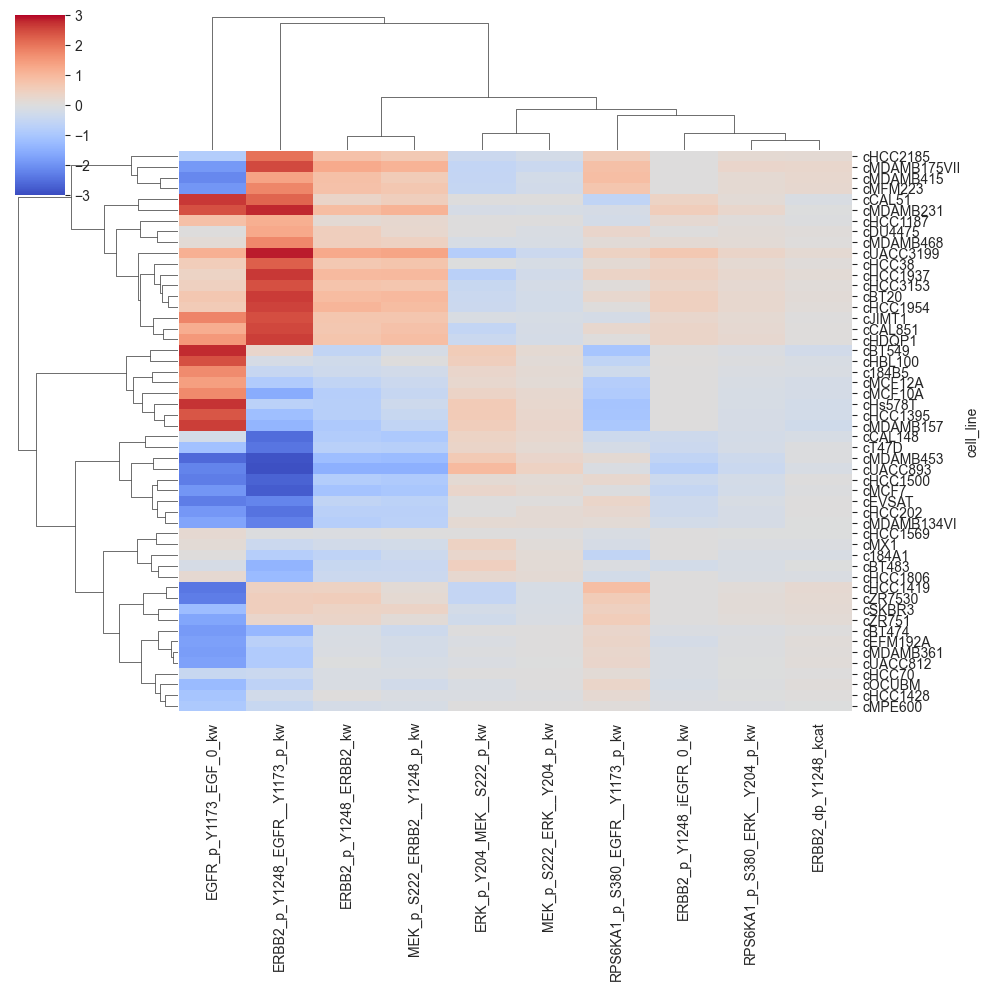

['ERBB2_p_Y1248_EGFR__Y1173_p_kw' 'ERBB2_p_Y1248_ERBB2_kw'
 'MEK_p_S222_ERBB2__Y1248_p_kw' 'ERK_p_Y204_MEK__S222_p_kw'
 'RPS6KA1_p_S380_EGFR__Y1173_p_kw' 'ERBB2_p_Y1248_iEGFR_0_kw'
 'MEK_p_S222_ERK__Y204_p_kw' 'RPS6KA1_p_S380_ERK__Y204_p_kw'
 'EGFR_p_Y1173_EGF_0_kw' 'ERBB2_dp_Y1248_kcat' 'EGFR_p_Y1173_iEGFR_0_kw'
 'ERK_p_Y204_iMEK_0_kw' 'MEK_p_S222_bact' 'MEK_p_S222_EGFR__Y1173_p_kw'
 'ERK_p_Y204_EGFR__Y1173_p_kw']


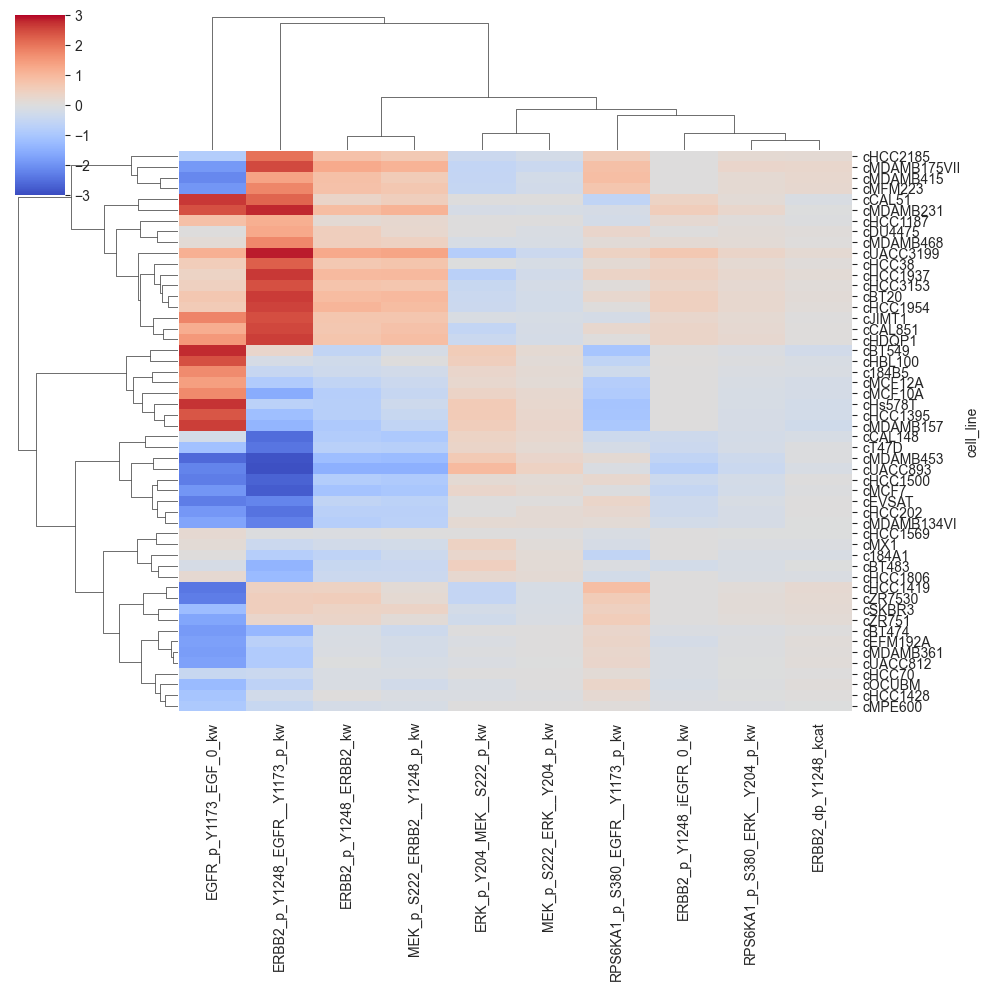

['ERBB2_p_Y1248_EGFR__Y1173_p_kw' 'ERBB2_p_Y1248_ERBB2_kw'
 'MEK_p_S222_ERBB2__Y1248_p_kw' 'ERK_p_Y204_MEK__S222_p_kw'
 'RPS6KA1_p_S380_EGFR__Y1173_p_kw' 'ERBB2_p_Y1248_iEGFR_0_kw'
 'MEK_p_S222_ERK__Y204_p_kw' 'RPS6KA1_p_S380_ERK__Y204_p_kw'
 'EGFR_p_Y1173_EGF_0_kw' 'ERBB2_dp_Y1248_kcat' 'EGFR_p_Y1173_iEGFR_0_kw'
 'ERK_p_Y204_iMEK_0_kw' 'MEK_p_S222_bact' 'MEK_p_S222_EGFR__Y1173_p_kw'
 'ERK_p_Y204_EGFR__Y1173_p_kw']


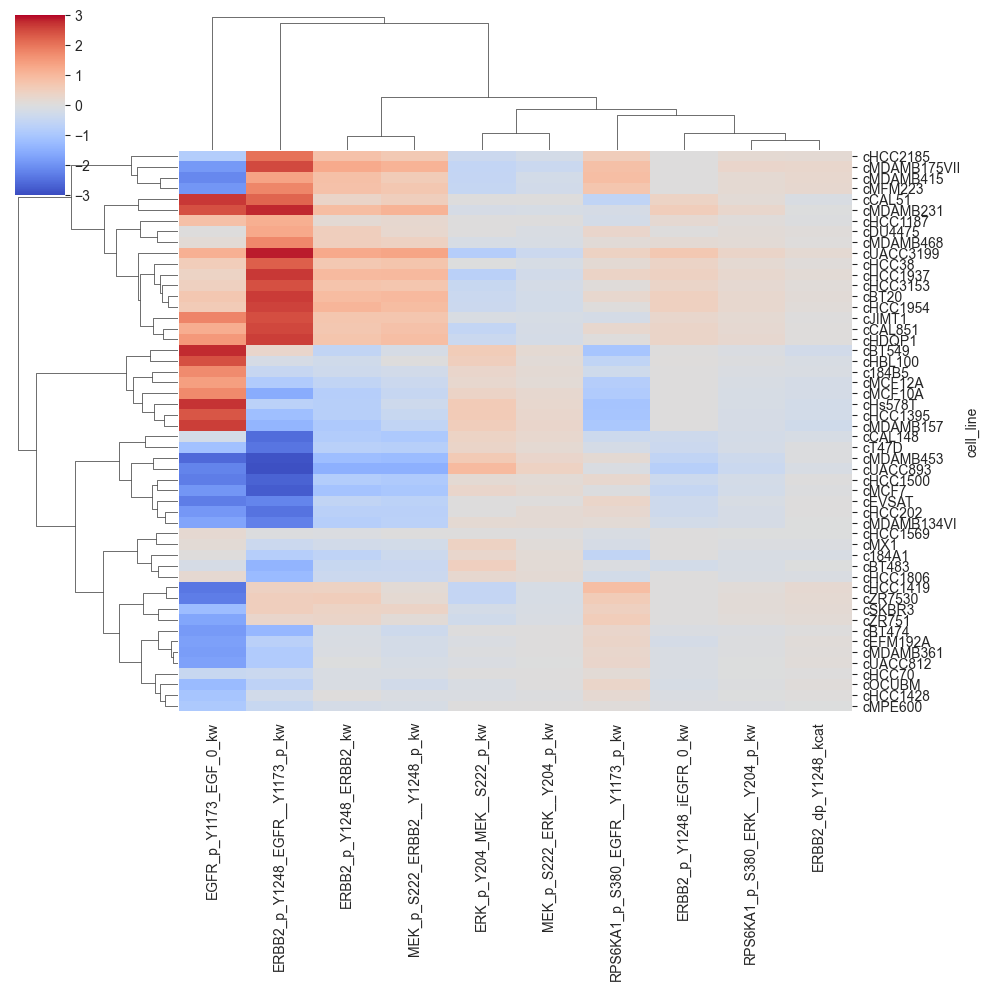

['ERBB2_p_Y1248_EGFR__Y1173_p_kw' 'ERBB2_p_Y1248_ERBB2_kw'
 'MEK_p_S222_ERBB2__Y1248_p_kw' 'ERK_p_Y204_MEK__S222_p_kw'
 'RPS6KA1_p_S380_EGFR__Y1173_p_kw' 'ERBB2_p_Y1248_iEGFR_0_kw'
 'MEK_p_S222_ERK__Y204_p_kw' 'RPS6KA1_p_S380_ERK__Y204_p_kw'
 'EGFR_p_Y1173_EGF_0_kw' 'ERBB2_dp_Y1248_kcat' 'EGFR_p_Y1173_iEGFR_0_kw'
 'ERK_p_Y204_iMEK_0_kw' 'MEK_p_S222_bact' 'MEK_p_S222_EGFR__Y1173_p_kw'
 'ERK_p_Y204_EGFR__Y1173_p_kw']


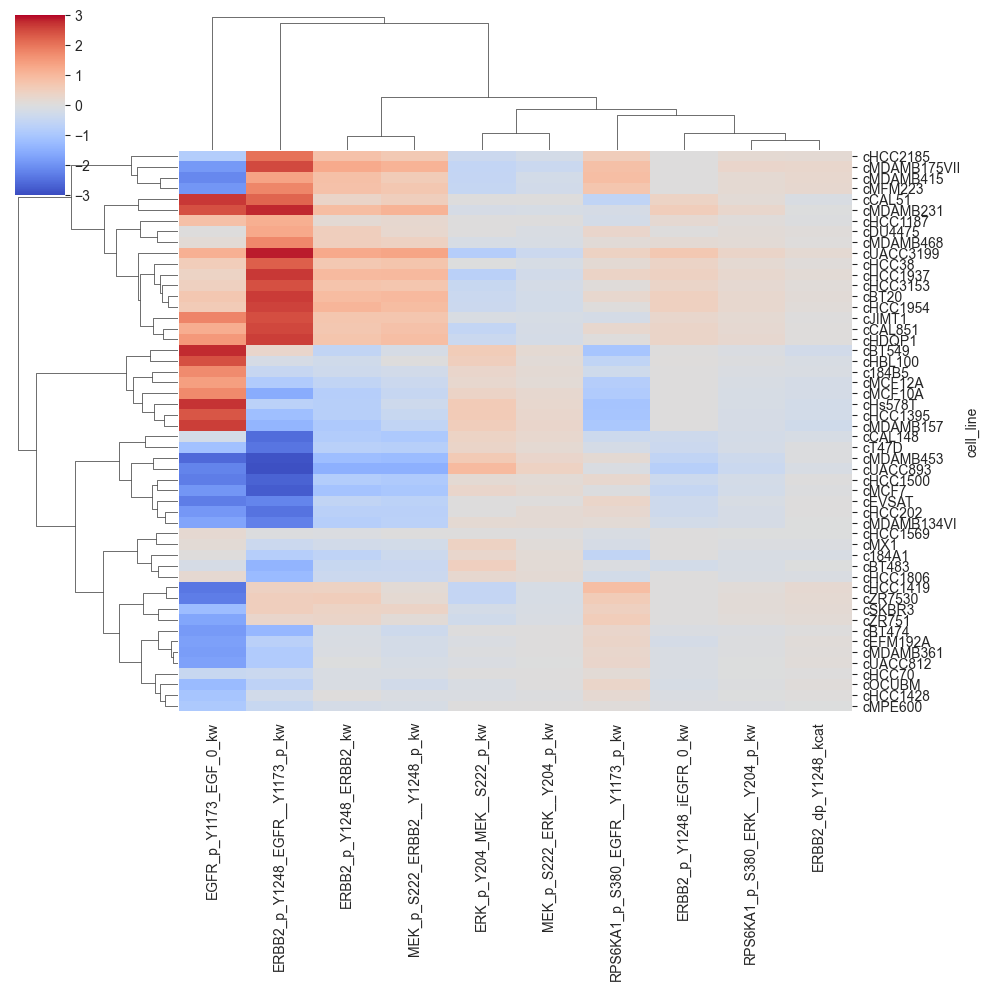

['ERBB2_p_Y1248_EGFR__Y1173_p_kw' 'ERBB2_p_Y1248_ERBB2_kw'
 'MEK_p_S222_ERBB2__Y1248_p_kw' 'ERK_p_Y204_MEK__S222_p_kw'
 'RPS6KA1_p_S380_EGFR__Y1173_p_kw' 'ERBB2_p_Y1248_iEGFR_0_kw'
 'MEK_p_S222_ERK__Y204_p_kw' 'RPS6KA1_p_S380_ERK__Y204_p_kw'
 'EGFR_p_Y1173_EGF_0_kw' 'ERBB2_dp_Y1248_kcat' 'EGFR_p_Y1173_iEGFR_0_kw'
 'ERK_p_Y204_iMEK_0_kw' 'MEK_p_S222_bact' 'MEK_p_S222_EGFR__Y1173_p_kw'
 'ERK_p_Y204_EGFR__Y1173_p_kw']


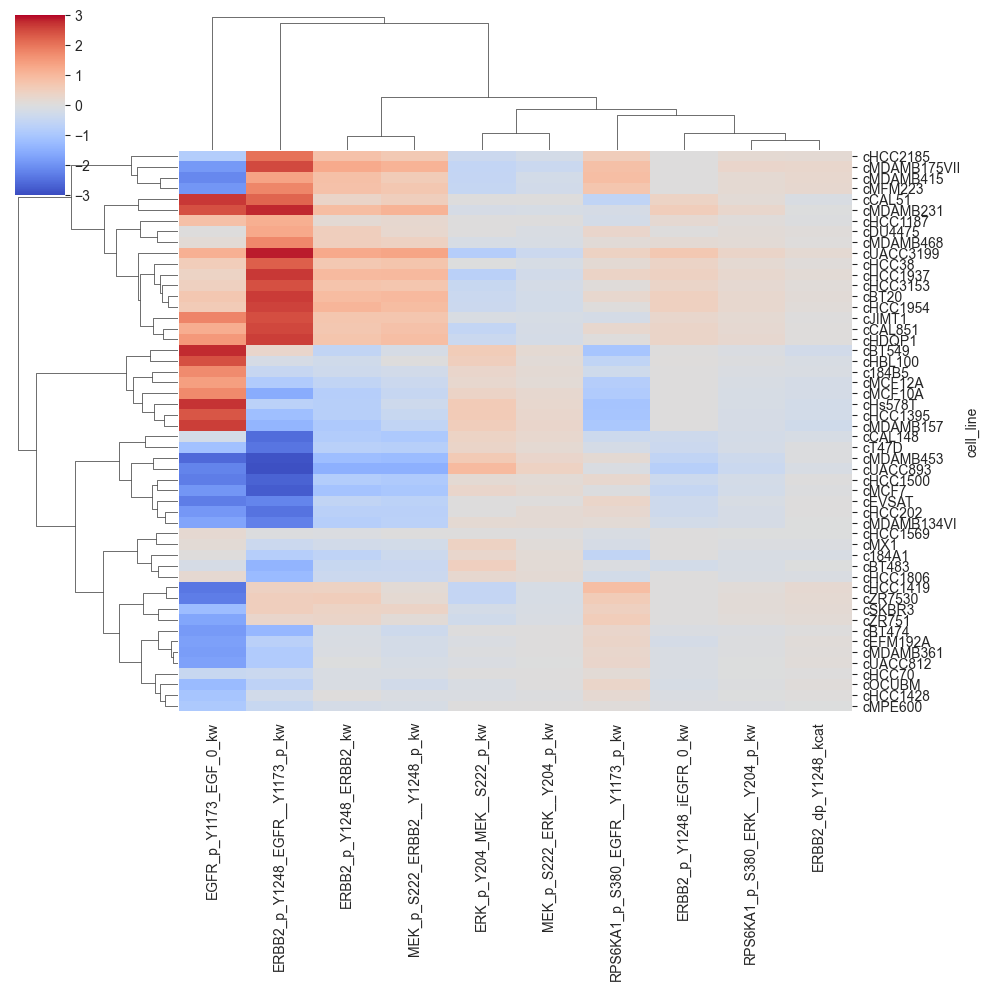

In [31]:
for samples in par_dev_df.samples.unique():
    sub_df = par_dev_df[(par_dev_df.context == "multimodal")]
    top_params = results_df[results_df.context == "multimodal"].sort_values(by="abs_diff", ascending=False).head(10).parameter.unique()
    print(results_df[results_df.context == "multimodal"].sort_values(by="abs_diff", ascending=False).head(15).parameter.unique())
    sub_df = sub_df.groupby("cell_line")[top_params].median().reset_index()
    sub_df.set_index("cell_line", inplace=True)
    sns.clustermap(
        sub_df[top_params],
        cmap="coolwarm",
        vmin=-3,
        vmax=3,
        yticklabels=True,
        xticklabels=True,
    )
    plt.show()

In [47]:
from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

samples = get_samples("dream_cytof")
petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK", data="dream_cytof"))
del petab_base_files["condition_table"]

transcriptomics, _, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
transcriptomics.sort_index(inplace=True)
terbb2 = transcriptomics["ERBB2"]
terbb2 -= terbb2.mean()
terbb3 = transcriptomics["ERBB3"]
terbb3 -= terbb3.mean()
del transcriptomics

proteomics, _, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
proteomics.sort_index(inplace=True)
perbb2 = proteomics["ERBB2"]
perbb2 -= perbb2.mean()
perbb3 = proteomics["ERBB3"]
perbb3 -= perbb3.mean()
del proteomics

MCF7 RPS6KA1_p_S380_EGFR__Y1173_p_kw tERBB3 0.5048752303630349
MCF7 RPS6KA1_p_S380_EGFR__Y1173_p_kw pERBB3 0.5048752303630349
MCF7 ERBB2_dp_Y1248_kcat tERBB3 0.552806943836857
MCF7 ERBB2_dp_Y1248_kcat pERBB3 0.552806943836857


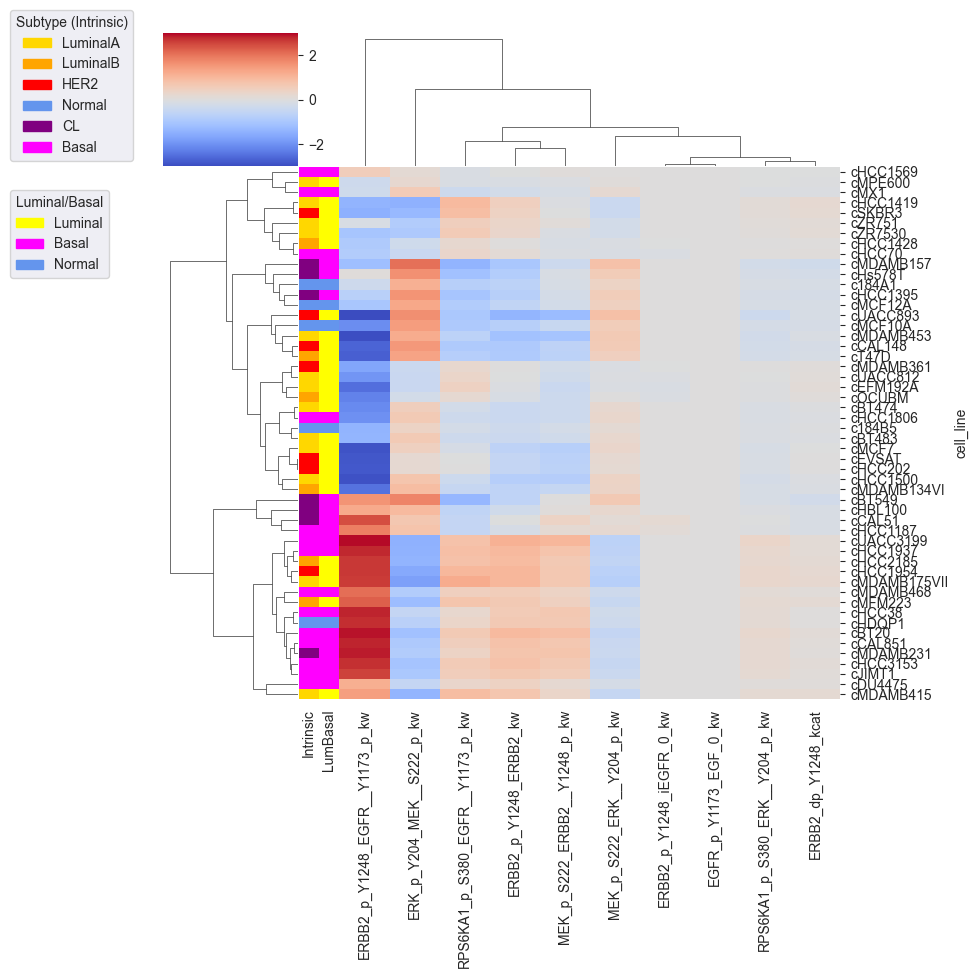

BT20 RPS6KA1_p_S380_EGFR__Y1173_p_kw tERBB3 0.7680439916220839
BT20 RPS6KA1_p_S380_EGFR__Y1173_p_kw pERBB3 0.7680439916220839
BT20 ERBB2_p_Y1248_iEGFR_0_kw tERBB3 -0.6122909523311102
BT20 ERBB2_p_Y1248_iEGFR_0_kw pERBB3 -0.6122909523311102
BT20 EGFR_p_Y1173_EGF_0_kw tERBB3 -0.7283746191054686
BT20 EGFR_p_Y1173_EGF_0_kw pERBB3 -0.7283746191054686


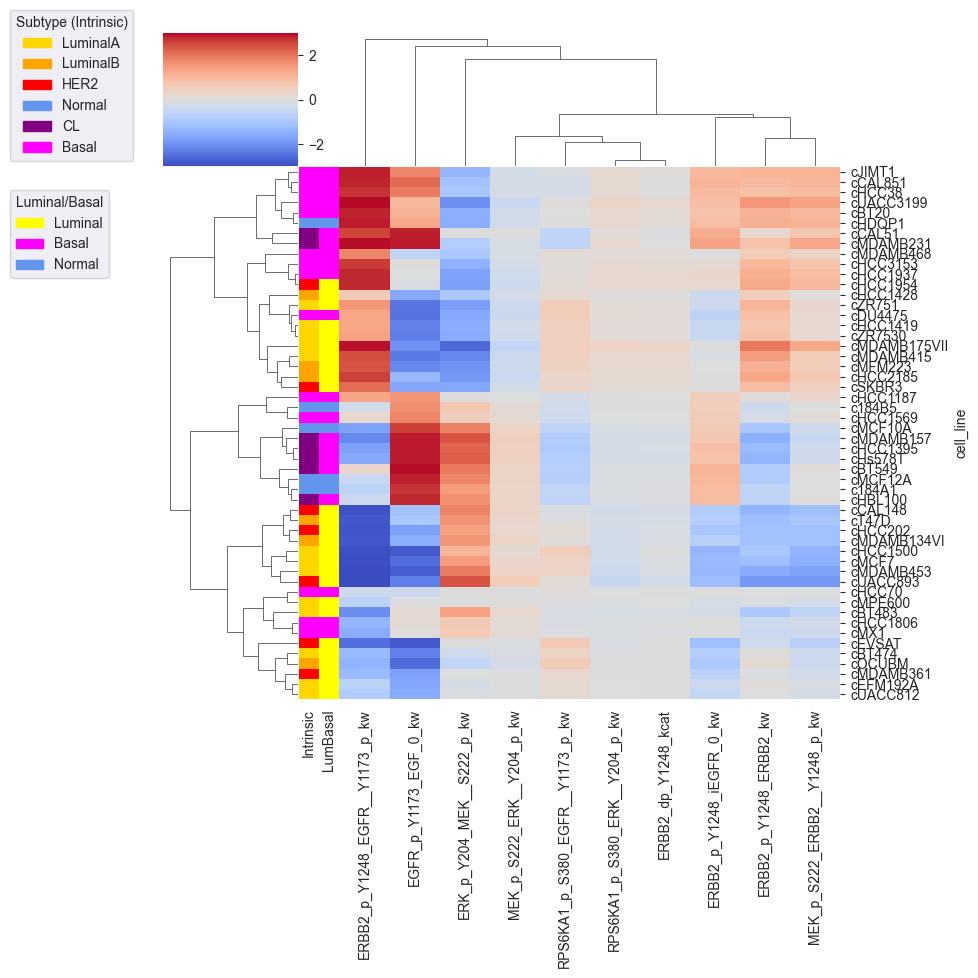

HCC1500 RPS6KA1_p_S380_EGFR__Y1173_p_kw tERBB2 0.5018074473957597
HCC1500 RPS6KA1_p_S380_EGFR__Y1173_p_kw tERBB3 0.7796905231769662
HCC1500 RPS6KA1_p_S380_EGFR__Y1173_p_kw pERBB2 0.5018074473957597
HCC1500 RPS6KA1_p_S380_EGFR__Y1173_p_kw pERBB3 0.7796905231769662
HCC1500 EGFR_p_Y1173_EGF_0_kw tERBB3 -0.7312910415355258
HCC1500 EGFR_p_Y1173_EGF_0_kw pERBB3 -0.7312910415355258
HCC1500 ERBB2_dp_Y1248_kcat tERBB3 0.6157106328534497
HCC1500 ERBB2_dp_Y1248_kcat pERBB3 0.6157106328534497


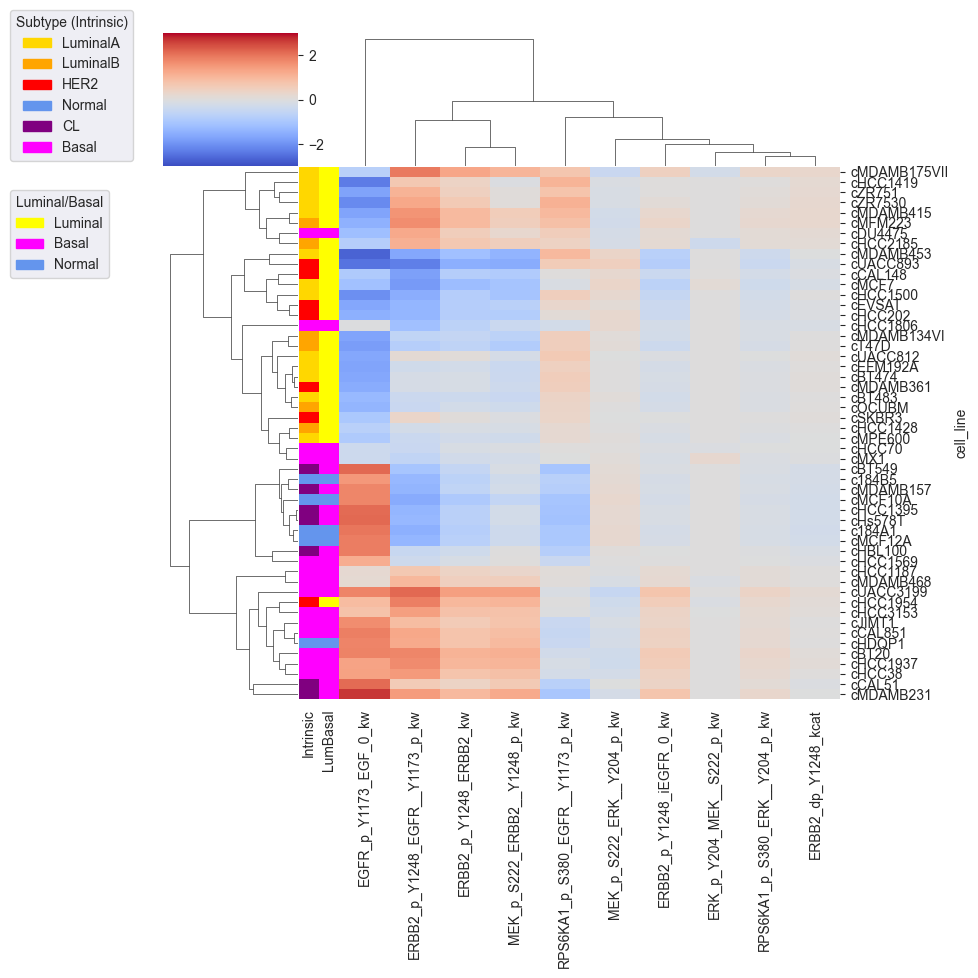

EVSAT ERBB2_p_Y1248_iEGFR_0_kw tERBB3 -0.6759454332657844
EVSAT ERBB2_p_Y1248_iEGFR_0_kw pERBB3 -0.6759454332657844
EVSAT EGFR_p_Y1173_EGF_0_kw tERBB2 -0.5075737196335349
EVSAT EGFR_p_Y1173_EGF_0_kw tERBB3 -0.7690343605005184
EVSAT EGFR_p_Y1173_EGF_0_kw pERBB2 -0.5075737196335349
EVSAT EGFR_p_Y1173_EGF_0_kw pERBB3 -0.7690343605005184
EVSAT ERBB2_dp_Y1248_kcat tERBB3 0.8231375988043373
EVSAT ERBB2_dp_Y1248_kcat pERBB3 0.8231375988043373


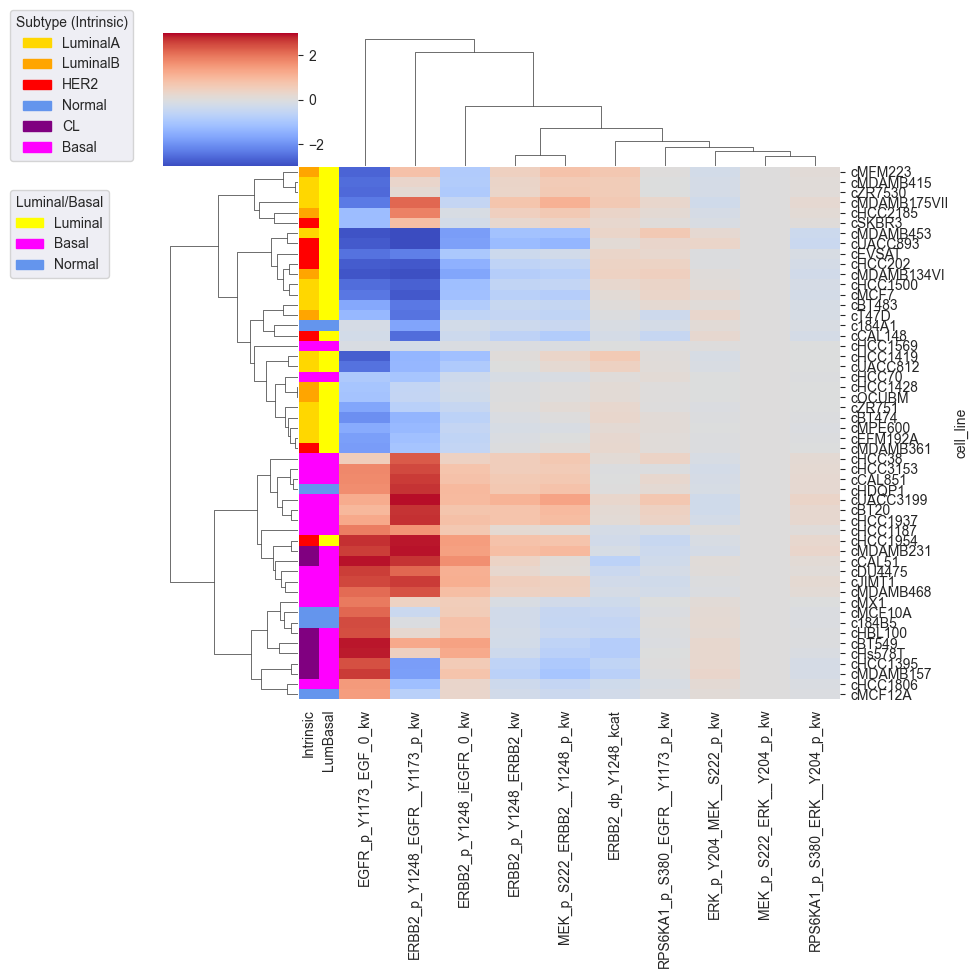

UACC3199 RPS6KA1_p_S380_EGFR__Y1173_p_kw tERBB3 0.7982715582429745
UACC3199 RPS6KA1_p_S380_EGFR__Y1173_p_kw pERBB3 0.7982715582429745
UACC3199 EGFR_p_Y1173_EGF_0_kw tERBB2 -0.5184538483804142
UACC3199 EGFR_p_Y1173_EGF_0_kw tERBB3 -0.7813222468245319
UACC3199 EGFR_p_Y1173_EGF_0_kw pERBB2 -0.5184538483804142
UACC3199 EGFR_p_Y1173_EGF_0_kw pERBB3 -0.7813222468245319
UACC3199 ERBB2_dp_Y1248_kcat tERBB3 0.6689622816486215
UACC3199 ERBB2_dp_Y1248_kcat pERBB3 0.6689622816486215


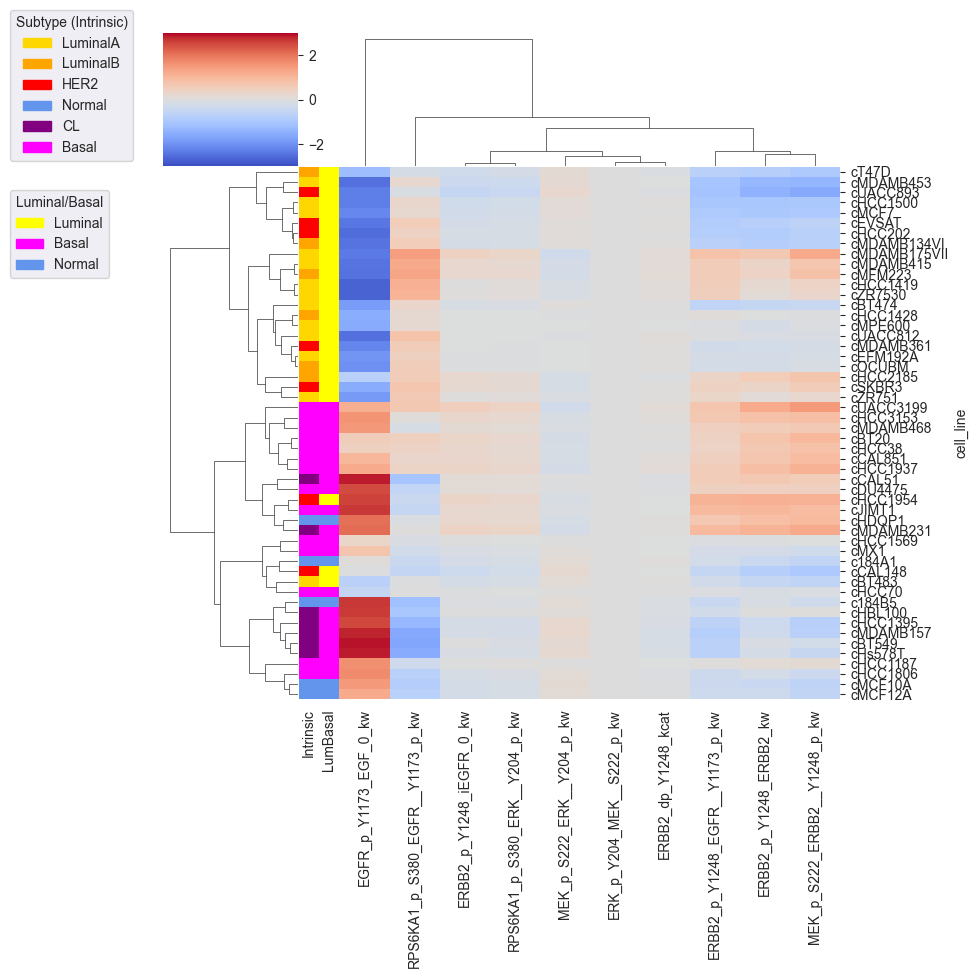

In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import warnings
from annotation_utils import load_marcotte_subtypes

warnings.filterwarnings("ignore")

subtypes_marcotte = load_marcotte_subtypes(par_dev_df.cell_line.unique())


# --- 1) Pick top parameters (your logic) ---
sub_df0 = par_dev_df[par_dev_df.context == "multimodal"].copy()

top_params = (
    results_df[results_df.context == "multimodal"]
    .sort_values("abs_diff", ascending=False)
    .parameter.unique()[:10]
)

# aggregate across jobs/splits per cell line (median) -> rows=cell_line, cols=top_params
# sub_df = (
#     sub_df0.groupby("cell_line")[list(top_params)]
#     .median()
#     .reset_index()
#     .set_index("cell_line")
#     .sort_index()
# )

# --- 2) Bring in subtype annotations and create Luminal/Basal collapsed label ---
# (You already built `subtypes_marcotte` above; reuse it here.)
ann = subtypes_marcotte.copy()
ann["luminalbasal"] = ann["subtype_intrinsic"].replace(
    {"LuminalA": "Luminal", "LuminalB": "Luminal", "HER2": "Luminal", "CL": "Basal"}
)

# Align annotations to clustermap index; fill missing
ann = ann.reindex(sub_df.index)
ann["subtype_intrinsic"] = ann["subtype_intrinsic"].fillna("Unknown")
ann["luminalbasal"] = ann["luminalbasal"].fillna("Unknown")

# --- 3) Color lookups for row annotations ---
intrinsic_order = ["LuminalA", "LuminalB", "HER2", "Normal", "CL", "Basal", "Unknown"]
lut_intrinsic = {
    "LuminalA": "gold",
    "LuminalB": "orange",
    "HER2": "red",
    "CL": "purple",
    "Basal": "magenta",
    "Normal": "cornflowerblue",
    "Unknown": "darkgray",
}

lb_order = ["Luminal", "Basal", "Normal", "Unknown"]
lut_lb = {
    "Luminal": "yellow",
    "Basal": "magenta",
    "Normal": "cornflowerblue",
    "Unknown": "darkgray",
}

row_colors = pd.DataFrame({
    "Intrinsic": ann["subtype_intrinsic"].map(lut_intrinsic),
    "LumBasal": ann["luminalbasal"].map(lut_lb),
}, index=sub_df.index)

# --- 5) Plot clustermap with annotations ---
for samples in ["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"]:
    sub_df = (
        sub_df0[sub_df0.samples == samples].groupby("cell_line")[list(top_params)]
        .median()
        .reset_index()
        .set_index("cell_line")
        .sort_index()
    )
    for param in top_params:
        # if "ERBB2" not in param:
        #     continue
        for marker_array, label in zip([terbb2, terbb3, perbb2, perbb3], ["tERBB2", "tERBB3", "pERBB2", "pERBB3"]):
            corr = np.corrcoef(sub_df[param].values, marker_array)[0, 1]
            if np.abs(corr) > 0.5:
                print(samples, param, label, np.corrcoef(sub_df[param].values, marker_array)[0, 1])
    g = sns.clustermap(
        sub_df[top_params],
        cmap="coolwarm",
        vmin=-3, vmax=3,
        row_colors=row_colors,
        yticklabels=True,
        xticklabels=True,
        figsize=(10, 10),
    )

    # --- 6) Legends for the row/column annotations ---
    # Row legends
    row_patches_intrinsic = [Patch(color=lut_intrinsic[k], label=k) for k in intrinsic_order if k in ann["subtype_intrinsic"].unique()]
    row_patches_lb = [Patch(color=lut_lb[k], label=k) for k in lb_order if k in ann["luminalbasal"].unique()]


    # Place legends (use g.fig not plt)
    leg1 = g.fig.legend(handles=row_patches_intrinsic, title="Subtype (Intrinsic)", loc="upper left", bbox_to_anchor=(0.02, 0.98))
    leg2 = g.fig.legend(handles=row_patches_lb, title="Luminal/Basal", loc="upper left", bbox_to_anchor=(0.02, 0.80))

    # Avoid legend overlap with heatmap
    g.fig.subplots_adjust(left=0.18, top=0.95)
    plt.savefig(f"{samples}_clustermap_multimodal_1a_basemodel.svg")
    plt.show()

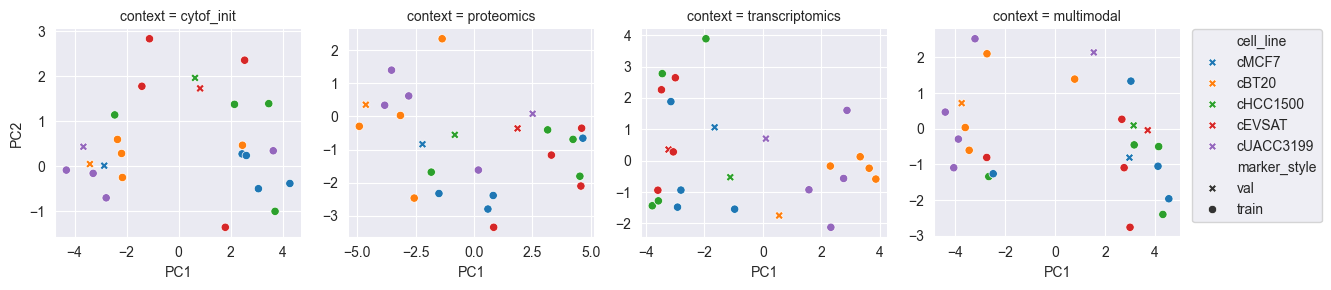

In [37]:
# Add a new column for marker style
pca_param_df["marker_style"] = pca_param_df.apply(
    lambda row: "val" if row.name[1:] == row["samples"] else "train",
    axis=1
)

# Define marker mapping
marker_dict = {"val": "X", "train": "o"}  # X for match, circle otherwise

g = sns.FacetGrid(
    pca_param_df[pca_param_df.index.isin(["cMCF7", "cBT20", "cHCC1500", "cEVSAT", "cUACC3199"])],
    col="context",
    col_order=["cytof_init", "proteomics", "transcriptomics", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="PC1",
    y="PC2",
    hue="cell_line",
    style="marker_style",        # use the new column for marker
    markers=marker_dict,         # assign specific markers
    hue_order=["cMCF7", "cBT20", "cHCC1500", "cEVSAT", "cUACC3199"]
)

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

In [ ]:
for context in sorted(median_par_dev_df.context.unique()):
    for samples in ["MCF7", "BT20", "HCC1500", "EVSAT", "UACC3199"]:
        sub_df = median_par_dev_df[(median_par_dev_df["context"] == context) & (median_par_dev_df["samples"] == samples)]
        sns.clustermap(
            sub_df.set_index("cell_line")[param_cols],
            cmap="coolwarm",
            yticklabels=True,
        )
        plt.show()
